In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("datapackage.json")
#dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-30.zip")
trails = Trails(dp, interpolate_annual=True, debug=True)

#methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_592d90d85ab3ba07ecc1471b0d8adddb69a0cb5531d0d21f24324d06f991dc27


In [2]:
from trails.plotting import plot_temporal_graph

trails.temporal_routing(
  start_year=2050,
  start_act_idx=13,
  amount=1.0,
  max_depth=3,
  show_progress=True,
  attribute_to_roots=True,
)

trails.lca(
    methods=methods,
    show_progress=True,
    compute_score=True,
    store_inventory=True,
)

Temporal routing: 1259node [00:01, 1011.24node/s]
Temporal LCA: solve years: 100%|█████████████| 41/41 [00:00<00:00, 424.78year/s]


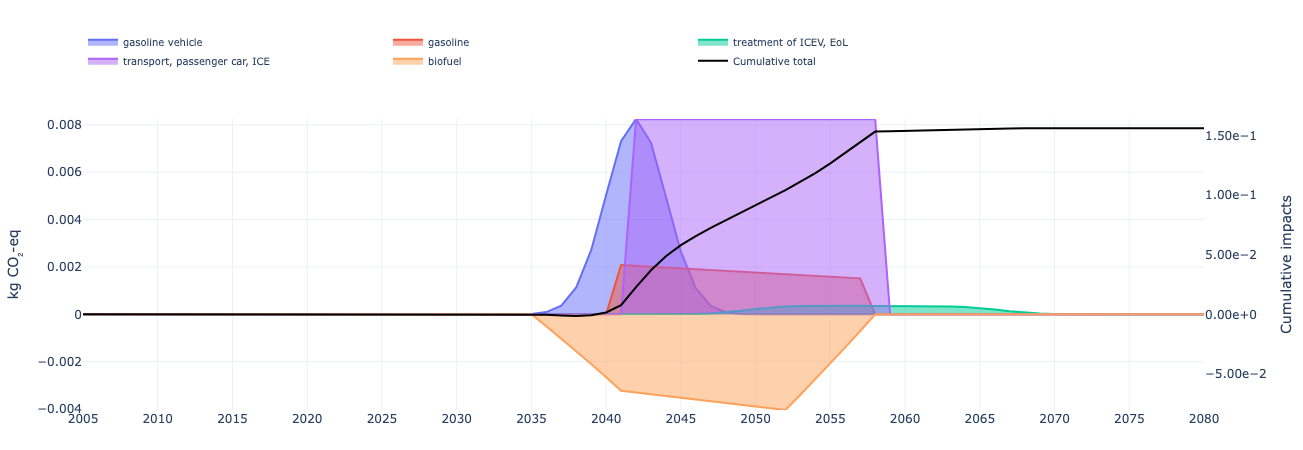

In [3]:
fig = plot_temporal_scores(
    stacked=False,
    legend_top_n=5,
    show_flow_contributions=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2080),
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=trails.static_score,
    static_score_dash= "dot",
    static_score_color= "red",
    #y_max=0.001,
    #y2_max=0.005
)
fig.show()

In [4]:
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
    trails,
    scenario="high-extension",
    scale_target_fraction=0.1,
)

/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

FaIR per-species: 100%|████████████| 2/2 [00:39<00:00, 19.51s/specie, CO2 AFOLU]


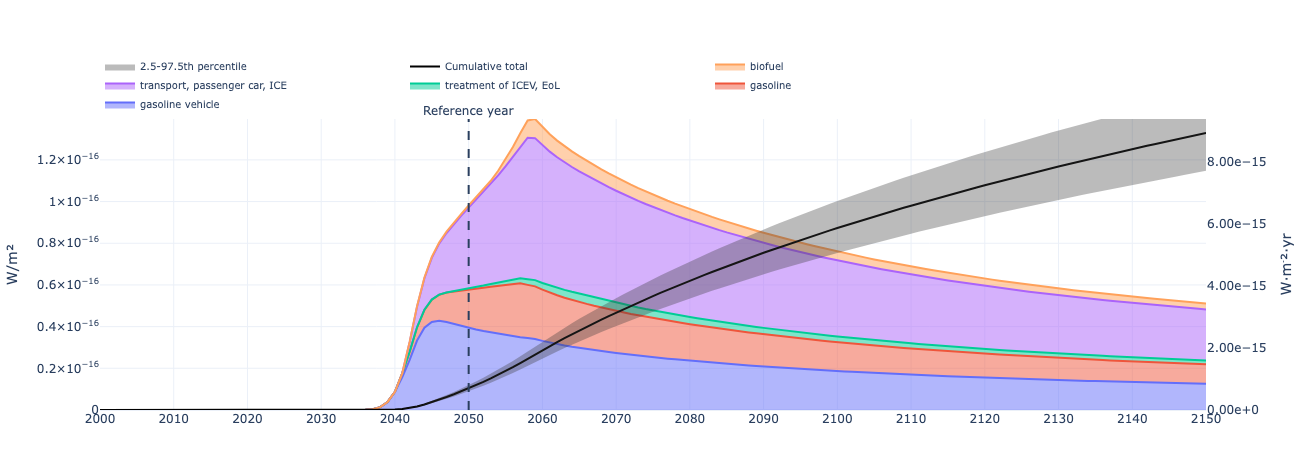

In [5]:
from trails.plotting import plot_rf

fig = plot_rf(
    trails=trails,
    reference_year=2050,
    #by="flow",
    year_range=(2000, 2150),
    year_tick=10,
)
fig.show()

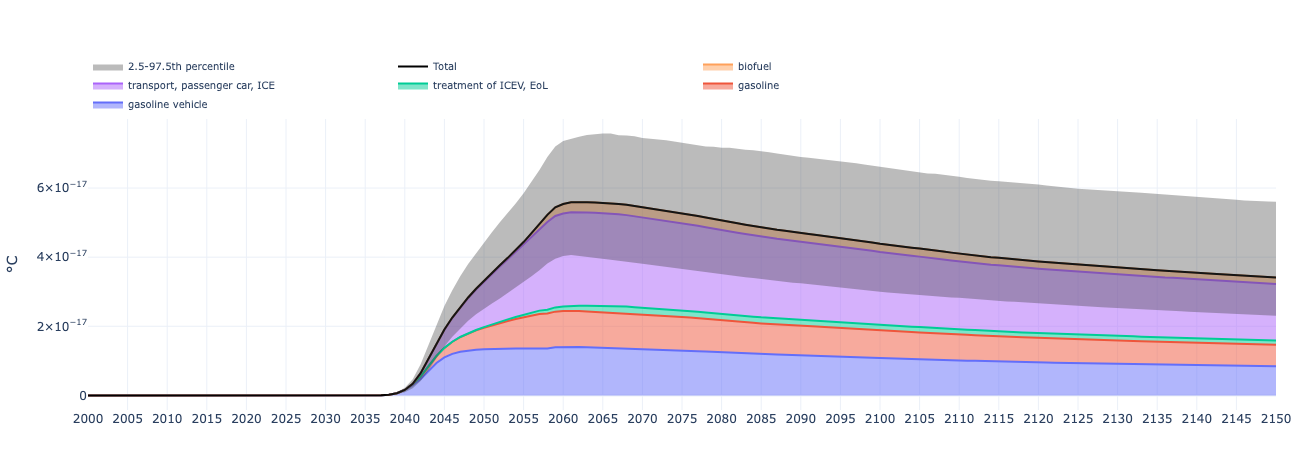

In [6]:
from trails import plot_temp

plot_temp(
    trails,
    by="root activity",
    title="Temperature change by root activity",
    method_label="°C",
    year_range=(2000, 2150),
)